# Warmstarting analysis: SCP-ART trajectories by behavior mode

Loads `ws_analysis_{ws_version}.npz` and plots **SCP solutions after ART-ctg warmstart** (`states_scp_DT_ctg`).

- **Overview:** one figure with a **9×3 grid** (27 panels), one per behavior mode 0–26.
- **Optional:** 27 separate full-size PNGs (`SAVE_PNG = True`).

Encoding: `region_id = behavior % 9`, `time_id = behavior // 9` → k_T ∈ {60, 80, 100}.

See **Semantic correctness** below for region + entry-time statistics per behavior mode.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

# freeflyer root (notebook lives in freeflyer/test/)
_here = Path.cwd().resolve()
root_folder = _here if (_here / "optimization").is_dir() else _here.parent
sys.path.insert(0, str(root_folder))

import optimization.ff_scenario as ff

ws_version = "v_01_seen"  # match warmstarting_analysis.py
npz_path = root_folder / "optimization" / "saved_files" / "warmstarting" / f"ws_analysis_{ws_version}.npz"
assert npz_path.is_file(), f"Missing {npz_path}"

data = np.load(npz_path, allow_pickle=True)
states_scp = data["states_scp_DT_ctg"]  # (N, 6, n_time+1)
behavior = data["behavior"].astype(int)
state_final = data["state_final"]  # (N, 6)
state_init = data["state_init"]

unfeas = data["i_unfeas_DT_ctg"]
if unfeas.size == 0:
    feasible = np.ones(len(behavior), dtype=bool)
else:
    feasible = np.ones(len(behavior), dtype=bool)
    feasible[unfeas.astype(int)] = False

n_time = states_scp.shape[2] - 1
print(npz_path.name, "N=", len(behavior), "feasible SCP-ART:", feasible.sum())

ws_analysis_v_01_seen.npz N= 1500 feasible SCP-ART: 1500


## Semantic correctness (SCP-ART vs behavior mode)

For each feasible trajectory:

1. **Region:** final $(x,y)$ must lie inside the **goal region** for `region_id = behavior % 9` (same 3×3 grid as data gen, $x>1.2$).
2. **Entry time:** index of the **first** timestep whose $(x,y)$ enters that region must fall in the band for `time_id = behavior // 9`:
   - time_id **0** (k_T=60): first entry index **&lt; 60**
   - time_id **1** (k_T=80): **60 ≤** first entry **&lt; 80**
   - time_id **2** (k_T=100): **80 ≤** first entry **&lt; 100**

Statistics below: counts **within each behavior mode** (denominator = feasible SCP-ART samples in that mode).

In [3]:
from dataset_generation.dataset_pargen import build_goal_regions_3x3_xgt12

_goal_regions = build_goal_regions_3x3_xgt12()


def _xy_in_region(xy, region):
    xlo, xhi, ylo, yhi = region
    return bool(xlo <= xy[0] <= xhi and ylo <= xy[1] <= yhi)


def first_timestep_in_region(traj_xy, region):
    """traj_xy shape (2, T+1). Return first t with (x,y) in region, or None."""
    T1 = traj_xy.shape[1]
    for t in range(T1):
        if _xy_in_region(traj_xy[:, t], region):
            return t
    return None


def entry_time_matches_time_id(first_t, time_id):
    if first_t is None:
        return False
    if time_id == 0:
        return first_t < 60
    if time_id == 1:
        return 60 <= first_t < 80
    return 80 <= first_t < 100


def semantic_checks_scp_art(states_scp_i, behavior_bm):
    """
    states_scp_i: (6, n_time+1)
    Returns dict with region_ok, time_ok, both_ok, first_entry_t, region_id, time_id.
    """
    rid = int(behavior_bm % 9)
    tid = int(behavior_bm // 9)
    reg = _goal_regions[rid]
    xy = states_scp_i[0:2, :]
    final_xy = xy[:, -1]
    region_ok = _xy_in_region(final_xy, reg)
    ft = first_timestep_in_region(xy, reg)
    time_ok = entry_time_matches_time_id(ft, tid)
    return {
        "region_ok": region_ok,
        "time_ok": time_ok,
        "both_ok": region_ok and time_ok,
        "first_entry_t": ft,
        "region_id": rid,
        "time_id": tid,
    }


def per_behavior_semantic_stats(states_scp, behavior_arr, feasible_mask):
    """Table: per behavior mode 0..26."""
    rows = []
    for bm in range(27):
        idx = np.flatnonzero(feasible_mask & (behavior_arr == bm))
        n = len(idx)
        if n == 0:
            rows.append(
                {
                    "behavior": bm,
                    "region_id": bm % 9,
                    "time_id": bm // 9,
                    "n_total": 0,
                    "n_region_ok": 0,
                    "n_time_ok": 0,
                    "n_both_ok": 0,
                    "pct_region": np.nan,
                    "pct_time": np.nan,
                    "pct_both": np.nan,
                }
            )
            continue
        nr = nt = nb = 0
        for i in idx:
            c = semantic_checks_scp_art(states_scp[i], bm)
            nr += int(c["region_ok"])
            nt += int(c["time_ok"])
            nb += int(c["both_ok"])
        rows.append(
            {
                "behavior": bm,
                "region_id": bm % 9,
                "time_id": bm // 9,
                "n_total": n,
                "n_region_ok": nr,
                "n_time_ok": nt,
                "n_both_ok": nb,
                "pct_region": 100.0 * nr / n,
                "pct_time": 100.0 * nt / n,
                "pct_both": 100.0 * nb / n,
            }
        )
    return rows


stats_rows = per_behavior_semantic_stats(states_scp, behavior, feasible)

try:
    import pandas as pd

    df = pd.DataFrame(stats_rows)
    display(
        df.style.format(
            {
                "pct_region": "{:.1f}%",
                "pct_time": "{:.1f}%",
                "pct_both": "{:.1f}%",
            },
            na_rep="—",
        )
    )
except ImportError:
    print(f"{'bm':>4} {'rid':>3} {'tid':>3} {'n':>4} {'reg':>4} {'time':>4} {'both':>4} {'%both':>6}")
    for r in stats_rows:
        if r["n_total"] == 0:
            print(f"{r['behavior']:4d} {r['region_id']:3d} {r['time_id']:3d} {'0':>4} {'—':>4} {'—':>4} {'—':>4} {'—':>6}")
        else:
            print(
                f"{r['behavior']:4d} {r['region_id']:3d} {r['time_id']:3d} {r['n_total']:4d} "
                f"{r['n_region_ok']:4d} {r['n_time_ok']:4d} {r['n_both_ok']:4d} {r['pct_both']:5.1f}%"
            )

# Overall (all feasible SCP-ART)
idx_all = np.flatnonzero(feasible)
N = len(idx_all)
if N:
    R = T = B = 0
    for i in idx_all:
        c = semantic_checks_scp_art(states_scp[i], int(behavior[i]))
        R += int(c["region_ok"])
        T += int(c["time_ok"])
        B += int(c["both_ok"])
    print(
        f"\n=== All feasible SCP-ART (N={N}) ===\n"
        f"  final xy in target region: {R}/{N} ({100 * R / N:.1f}%)\n"
        f"  first-entry time band ok:  {T}/{N} ({100 * T / N:.1f}%)\n"
        f"  both conditions:           {B}/{N} ({100 * B / N:.1f}%)"
    )

,behavior,region_id,time_id,n_total,n_region_ok,n_time_ok,n_both_ok,pct_region,pct_time,pct_both
0,0,0,0,47,47,47,47,100.0%,100.0%,100.0%
1,1,1,0,55,50,53,50,90.9%,96.4%,90.9%
2,2,2,0,49,49,49,49,100.0%,100.0%,100.0%
3,3,3,0,58,57,58,57,98.3%,100.0%,98.3%
4,4,4,0,58,56,56,56,96.6%,96.6%,96.6%
5,5,5,0,58,55,57,55,94.8%,98.3%,94.8%
6,6,6,0,61,61,61,61,100.0%,100.0%,100.0%
7,7,7,0,50,47,49,47,94.0%,98.0%,94.0%
8,8,8,0,57,54,56,54,94.7%,98.2%,94.7%
9,9,0,1,65,65,65,65,100.0%,100.0%,100.0%



=== All feasible SCP-ART (N=1500) ===
  final xy in target region: 1466/1500 (97.7%)
  first-entry time band ok:  1299/1500 (86.6%)
  both conditions:           1287/1500 (85.8%)


In [4]:
def draw_scene(ax, axis_labels=True):
    tab = ff.table
    ax.add_patch(
        Rectangle(
            (tab["xy_low"][0], tab["xy_low"][1]),
            tab["xy_up"][0] - tab["xy_low"][0],
            tab["xy_up"][1] - tab["xy_low"][1],
            fc=(0.55, 0.55, 0.6, 0.12),
            ec="k",
            lw=0.8,
            zorder=0,
        )
    )
    for n in range(ff.obs["position"].shape[0]):
        c = "crimson" if n == 1 else "#2a6f4a"
        ax.add_patch(
            Circle(
                ff.obs["position"][n],
                ff.obs["radius"][n],
                fc=c,
                ec="none",
                alpha=0.85,
                zorder=1,
            )
        )
        ax.add_patch(
            Circle(
                ff.obs["position"][n],
                ff.obs["radius"][n] + ff.robot_radius,
                fc="none",
                ec="k",
                ls="--",
                lw=0.4,
                alpha=0.35,
                zorder=1,
            )
        )
    ax.set_aspect("equal")
    ax.set_xlim(tab["xy_low"][0], tab["xy_up"][0])
    ax.set_ylim(tab["xy_low"][1], tab["xy_up"][1])
    if axis_labels:
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
    else:
        ax.tick_params(labelsize=5)
    ax.grid(True, alpha=0.25)

In [5]:
K_T_LABELS = {0: 60, 1: 80, 2: 100}

def plot_behavior_canvas(bm, save_dir=None):
    """All feasible SCP-ART xy trajectories for behavior mode bm (0..26)."""
    mask = (behavior == bm) & feasible
    idx = np.flatnonzero(mask)
    region_id = bm % 9
    time_id = bm // 9
    k_T = K_T_LABELS[time_id]

    fig, ax = plt.subplots(figsize=(7.2, 5.4), dpi=120)
    draw_scene(ax)

    cmap = plt.cm.viridis(np.linspace(0.15, 0.95, max(len(idx), 1)))
    for j, i in enumerate(idx):
        s = states_scp[i]
        if not np.all(np.isfinite(s[0:2, :])):
            continue
        ax.plot(s[0, :], s[1, :], color=cmap[j % len(cmap)], alpha=0.45, lw=1.0, zorder=2)
        ax.scatter(s[0, 0], s[1, 0], c=[cmap[j % len(cmap)]], s=12, zorder=3, ec="white", lw=0.3)
        ax.scatter(state_final[i, 0], state_final[i, 1], marker="*", s=55, c=[cmap[j % len(cmap)]], zorder=4, ec="k", lw=0.25)

    ax.set_title(
        f"SCP-ART | behavior {bm} | region {region_id} | k_T={k_T} | n={len(idx)} trajectories",
        fontsize=10,
    )
    plt.tight_layout()
    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / f"scp_art_behavior_{bm:02d}.png", bbox_inches="tight")
    return fig, ax

## All 27 behavior modes (one figure, 9×3 grid)

Each panel: SCP-ART xy paths for that behavior; starts (dots), goals (stars). Set `ws_version` above to match your run.

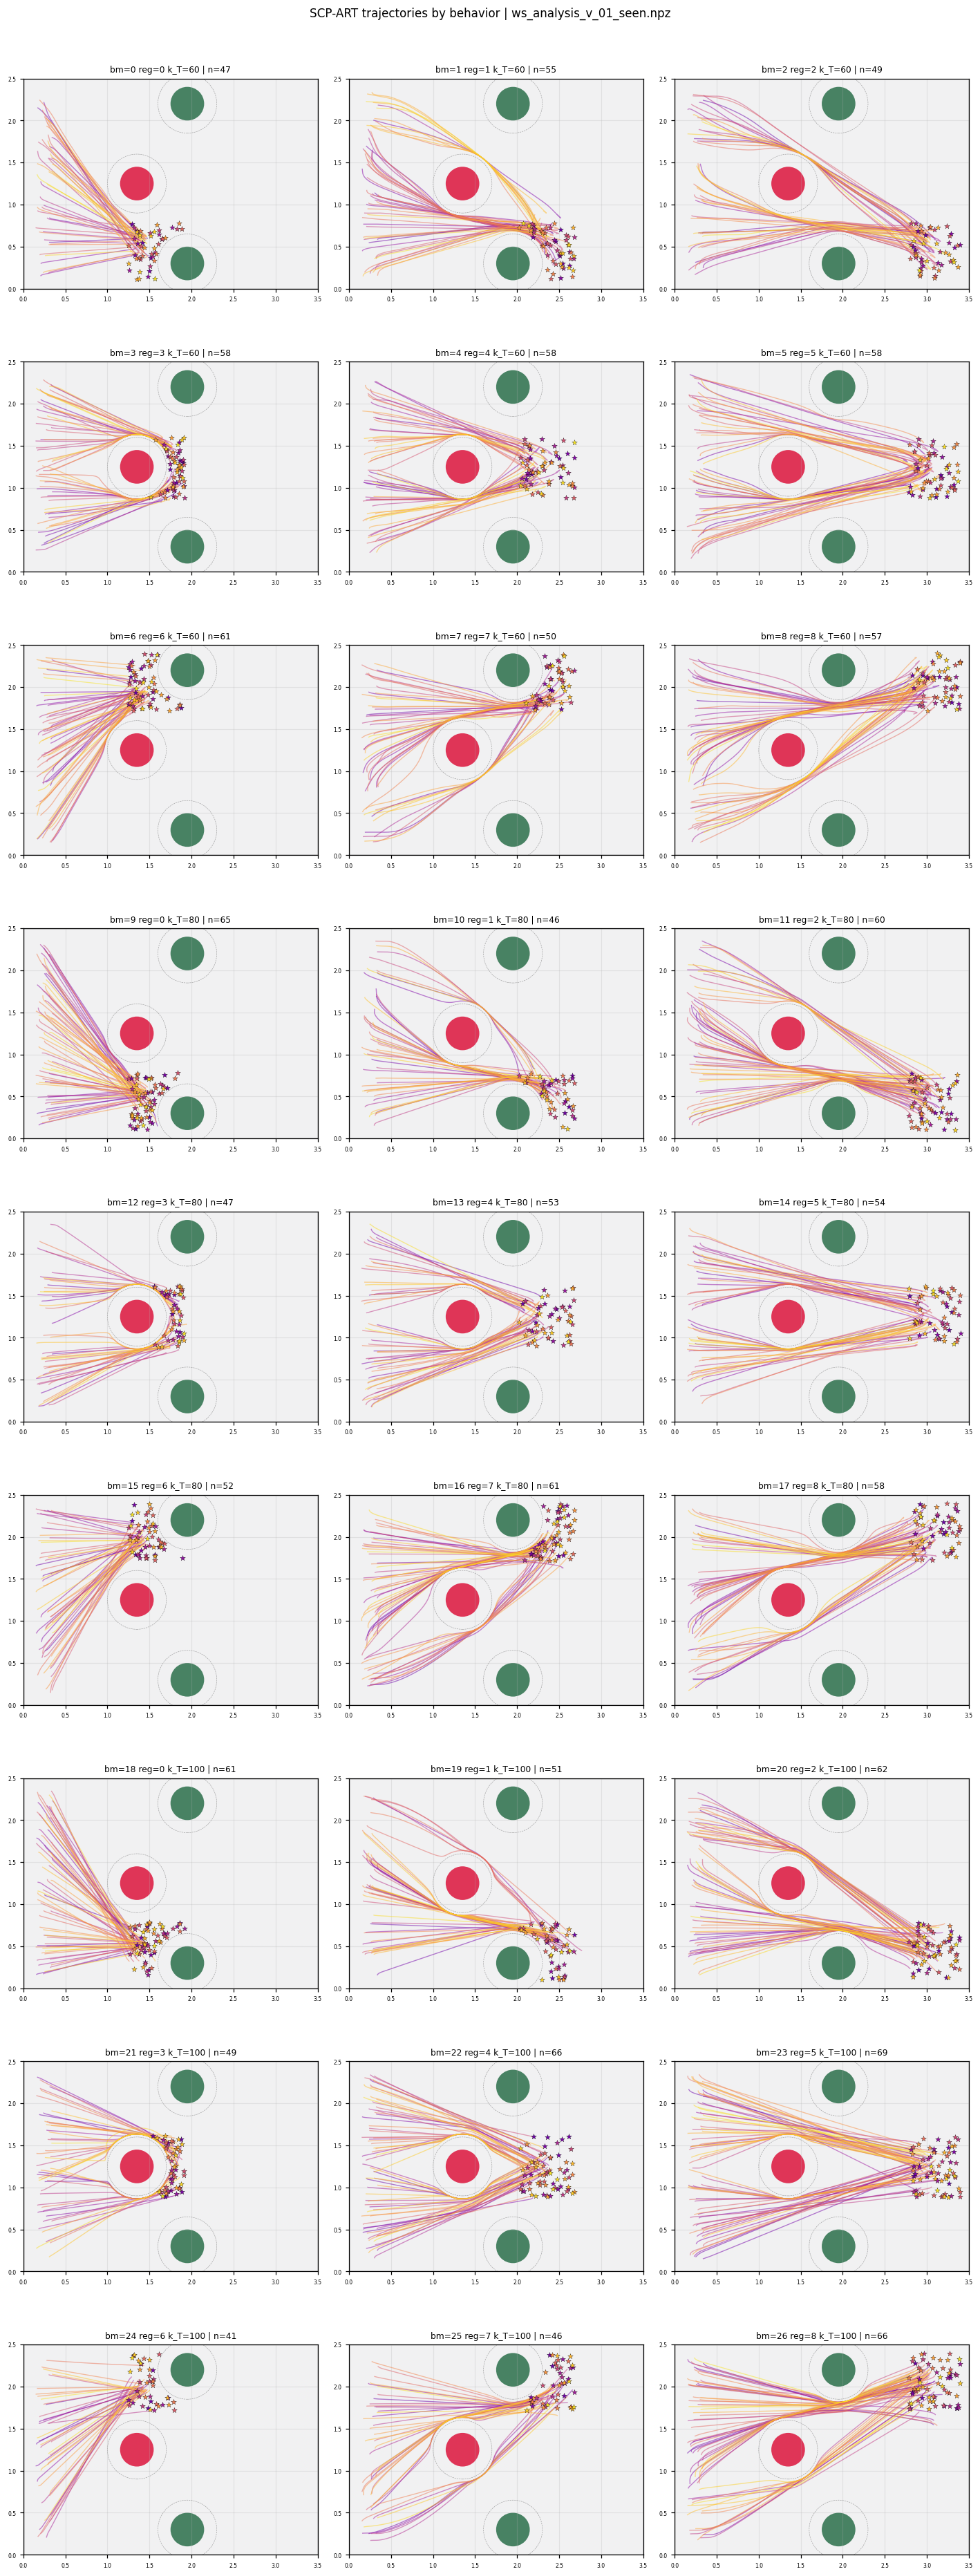

In [8]:
fig, axes = plt.subplots(9, 3, figsize=(13, 34), dpi=110)
k_choices = [60, 80, 100]
for bm, ax in enumerate(np.ravel(axes)):
    mask = (behavior == bm) & feasible
    idx = np.flatnonzero(mask)
    region_id, time_id = bm % 9, bm // 9
    draw_scene(ax, axis_labels=False)
    cmap = plt.cm.plasma(np.linspace(0.2, 0.95, max(len(idx), 1)))
    for j, i in enumerate(idx):
        s = states_scp[i]
        if not np.all(np.isfinite(s[0:2, :])):
            continue
        ax.plot(s[0, :], s[1, :], color=cmap[j % len(cmap)], alpha=0.5, lw=0.9, zorder=2)
        ax.scatter(state_final[i, 0], state_final[i, 1], marker="*", s=28, c=[cmap[j % len(cmap)]], zorder=4, ec="k", lw=0.2)
    ax.set_title(f"bm={bm} reg={region_id} k_T={k_choices[time_id]} | n={len(idx)}", fontsize=8)
plt.suptitle(f"SCP-ART trajectories by behavior | {npz_path.name}", fontsize=11, y=1.002)
plt.tight_layout()
plt.show()